<a href="https://colab.research.google.com/github/Manikanta-23-ai/Machine-Learning-Projects/blob/main/STOCK_PREDICTION_USING_MACHINE_LEARNING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import numpy as np # for linear algebra
import pandas as pd # data preprocessing
import matplotlib.pyplot as plt # data visualization library
import seaborn as sns # data visualization library
%matplotlib inline
import warnings
warnings.filterwarnings('ignore') # ignore warnings

from sklearn.preprocessing import MinMaxScaler # for normalization
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM, Bidirectional

In [20]:
df = pd.read_csv('/content/stock_dataset.csv') # data_importing
df.head(20)

,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,GOOG,2016-06-14 00:00:00+00:00,718.27,722.4700,713.1200,716.48,1306065,718.27,722.4700,713.1200,716.48,1306065,0.0,1.0
1,GOOG,2016-06-15 00:00:00+00:00,718.92,722.9800,717.3100,719.00,1214517,718.92,722.9800,717.3100,719.00,1214517,0.0,1.0
2,GOOG,2016-06-16 00:00:00+00:00,710.36,716.6500,703.2600,714.91,1982471,710.36,716.6500,703.2600,714.91,1982471,0.0,1.0
3,GOOG,2016-06-17 00:00:00+00:00,691.72,708.8200,688.4515,708.65,3402357,691.72,708.8200,688.4515,708.65,3402357,0.0,1.0
4,GOOG,2016-06-20 00:00:00+00:00,693.71,702.4800,693.4100,698.77,2082538,693.71,702.4800,693.4100,698.77,2082538,0.0,1.0
5,GOOG,2016-06-21 00:00:00+00:00,695.94,702.7700,692.0100,698.40,1465634,695.94,702.7700,692.0100,698.40,1465634,0.0,1.0
6,GOOG,2016-06-22 00:00:00+00:00,697.46,700.8600,693.0819,699.06,1184318,697.46,700.8600,693.0819,699.06,1184318,0.0,1.0
7,GOOG,2016-06-23 00:00:00+00:00,701.87,701.9500,687.0000,697.45,2171415,701.87,701.9500,687.0000,697.45,2171415,0.0,1.0
8,GOOG,2016-06-24 00:00:00+00:00,675.22,689.4000,673.4500,675.17,4449022,675.22,689.4000,673.4500,675.17,4449022,0.0,1.0
9,GOOG,2016-06-27 00:00:00+00:00,668.26,672.3000,663.2840,671.00,2641085,668.26,672.3000,663.2840,671.00,2641085,0.0,1.0


In [21]:
df.describe()

,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
count,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03,1258.0,1258.0
mean,1216.317067,1227.430934,1204.176430,1215.260779,1.601590e+06,1216.317067,1227.430936,1204.176436,1215.260779,1.601590e+06,0.0,1.0
std,383.333358,387.570872,378.777094,382.446995,6.960172e+05,383.333358,387.570873,378.777099,382.446995,6.960172e+05,0.0,0.0
min,668.260000,672.300000,663.284000,671.000000,3.467530e+05,668.260000,672.300000,663.284000,671.000000,3.467530e+05,0.0,1.0
25%,960.802500,968.757500,952.182500,959.005000,1.173522e+06,960.802500,968.757500,952.182500,959.005000,1.173522e+06,0.0,1.0
50%,1132.460000,1143.935000,1117.915000,1131.150000,1.412588e+06,1132.460000,1143.935000,1117.915000,1131.150000,1.412588e+06,0.0,1.0
75%,1360.595000,1374.345000,1348.557500,1361.075000,1.812156e+06,1360.595000,1374.345000,1348.557500,1361.075000,1.812156e+06,0.0,1.0
max,2521.600000,2526.990000,2498.290000,2524.920000,6.207027e+06,2521.600000,2526.990000,2498.290000,2524.920000,6.207027e+06,0.0,1.0


In [22]:
df.shape

(1258, 14)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   symbol       1258 non-null   object 
 1   date         1258 non-null   object 
 2   close        1258 non-null   float64
 3   high         1258 non-null   float64
 4   low          1258 non-null   float64
 5   open         1258 non-null   float64
 6   volume       1258 non-null   int64  
 7   adjClose     1258 non-null   float64
 8   adjHigh      1258 non-null   float64
 9   adjLow       1258 non-null   float64
 10  adjOpen      1258 non-null   float64
 11  adjVolume    1258 non-null   int64  
 12  divCash      1258 non-null   float64
 13  splitFactor  1258 non-null   float64
dtypes: float64(10), int64(2), object(2)
memory usage: 137.7+ KB


In [24]:
df.isnull().sum()

,0
symbol,0
date,0
close,0
high,0
low,0
open,0
volume,0
adjClose,0
adjHigh,0
adjLow,0


In [25]:
df = df[['date','open','close']] # Extracting required columns
df['date'] = pd.to_datetime(df['date'].apply(lambda x: x.split()[0])) # converting object dtype of date column to datetime dtype
df.set_index('date',drop=True,inplace=True) # Setting date column as index
df.head(20)

,open,close
date,,
2016-06-14,716.48,718.27
2016-06-15,719.00,718.92
2016-06-16,714.91,710.36
2016-06-17,708.65,691.72
2016-06-20,698.77,693.71
2016-06-21,698.40,695.94
2016-06-22,699.06,697.46
2016-06-23,697.45,701.87
2016-06-24,675.17,675.22


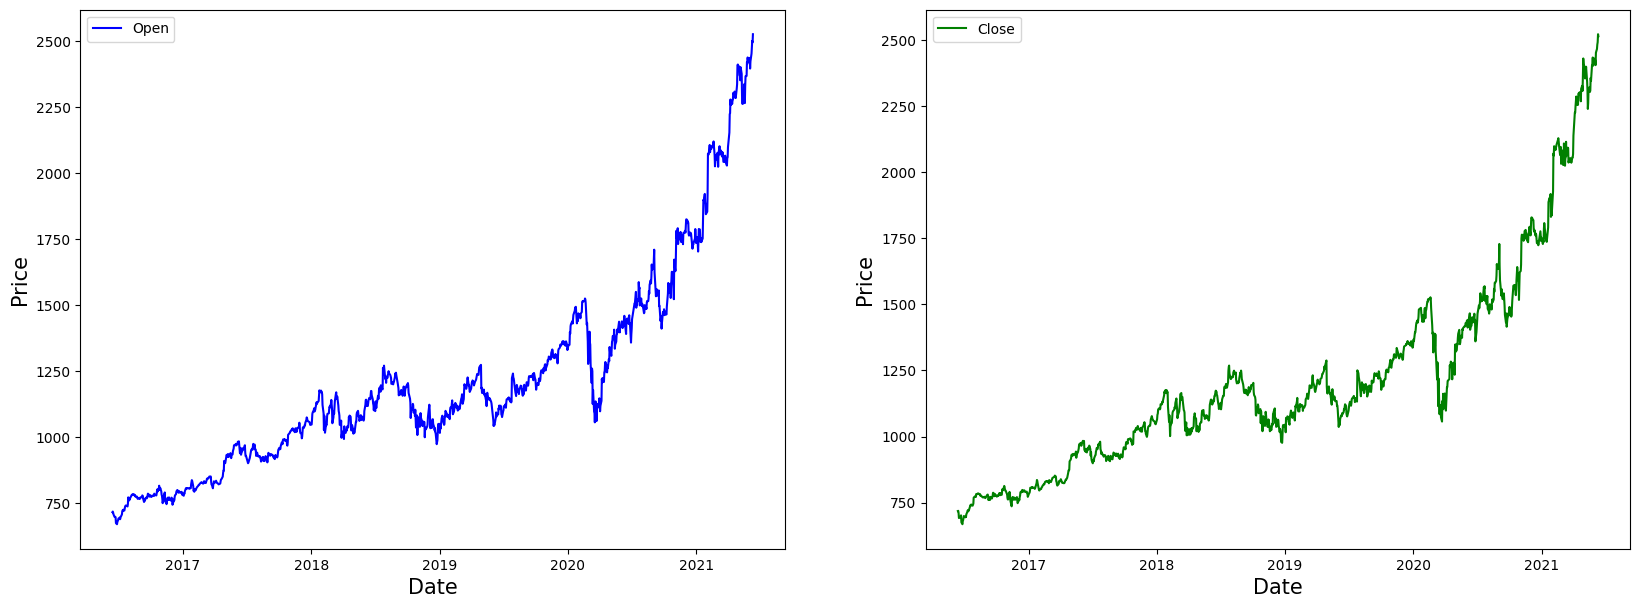

In [26]:

fig, ax =plt.subplots(1,2,figsize=(20,7))
ax[0].plot(df['open'],label='Open',color='blue')
ax[0].set_xlabel('Date',size=15)
ax[0].set_ylabel('Price',size=15)
ax[0].legend()

ax[1].plot(df['close'],label='Close',color='green')
ax[1].set_xlabel('Date',size=15)
ax[1].set_ylabel('Price',size=15)
ax[1].legend()

fig.show()

In [27]:
MMS = MinMaxScaler()
df[df.columns] = MMS.fit_transform(df)
df.head(20)

,open,close
date,,
2016-06-14,0.024532,0.026984
2016-06-15,0.025891,0.027334
2016-06-16,0.023685,0.022716
2016-06-17,0.020308,0.012658
2016-06-20,0.014979,0.013732
2016-06-21,0.014779,0.014935
2016-06-22,0.015135,0.015755
2016-06-23,0.014267,0.018135
2016-06-24,0.002249,0.003755


In [28]:
training_size = round(len(df) * 0.75)
training_size

944

In [29]:
train_data = df[:training_size]
test_data  = df[training_size:]

train_data.shape, test_data.shape

((944, 2), (314, 2))

In [30]:
def create_sequence(dataset):
  sequences = []
  labels = []

  start_idx = 0

  for stop_idx in range(50,len(dataset)): # Selecting 50 rows at a time
    sequences.append(dataset.iloc[start_idx:stop_idx])
    labels.append(dataset.iloc[stop_idx])
    start_idx += 1
  return (np.array(sequences),np.array(labels))

In [31]:
train_seq, train_label = create_sequence(train_data)
test_seq, test_label = create_sequence(test_data)
train_seq.shape, train_label.shape, test_seq.shape, test_label.shape

((894, 50, 2), (894, 2), (264, 50, 2), (264, 2))

In [32]:
model = Sequential()
# importing Dense, Dropout, LSTM, Bidirectional from keras.layers
model.add(LSTM(units=50, return_sequences=True, input_shape = (train_seq.shape[1], train_seq.shape[2])))

model.add(Dropout(0.1))
model.add(LSTM(units=50))

model.add(Dense(2))

model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mean_absolute_error'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 50, 50)         │        10,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,902 (120.71 KB)

 Trainable params: 30,902 (120.71 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
model.fit(train_seq, train_label, epochs=100,validation_data=(test_seq, test_label), verbose=1)

Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - loss: 0.0182 - mean_absolute_error: 0.1005 - val_loss: 0.0216 - val_mean_absolute_error: 0.1188
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - loss: 0.0013 - mean_absolute_error: 0.0291 - val_loss: 0.0105 - val_mean_absolute_error: 0.0822
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 4.8233e-04 - mean_absolute_error: 0.0166 - val_loss: 0.0050 - val_mean_absolute_error: 0.0540
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 4.1221e-04 - mean_absolute_error: 0.0145 - val_loss: 0.0067 - val_mean_absolute_error: 0.0635
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 4.2594e-04 - mean_absolute_error: 0.0148 - val_loss: 0.0038 - val_mean_absolute_error: 0.0461
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 4.4632e-04 - mean_absolute_error: 0.0158 - val_loss: 0.0053 - val_mean_absolute_error: 0.0555
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 3.6544e-04 - mean_absolu

In [34]:
test_predicted = model.predict(test_seq)
test_predicted[:5]

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step


array([[0.41491786, 0.41750526],
       [0.41489923, 0.4177611 ],
       [0.41185147, 0.4149694 ],
       [0.41588822, 0.41857666],
       [0.41955224, 0.42200184]], dtype=float32)

In [35]:
test_inverse_predicted = MMS.inverse_transform(test_predicted)
test_inverse_predicted[:5]

array([[1440.2245, 1442.0393],
       [1440.19  , 1442.5134],
       [1434.5397, 1437.3394],
       [1442.0234, 1444.0249],
       [1448.8163, 1450.3729]], dtype=float32)

In [36]:
df_merge = pd.concat([df.iloc[-264:].copy(),
                          pd.DataFrame(test_inverse_predicted,columns=['open_predicted','close_predicted'],
                                       index=df.iloc[-264:].index)], axis=1)

In [37]:
df_merge[['open','close']] = MMS.inverse_transform(df_merge[['open','close']])
df_merge.head()

,open,close,open_predicted,close_predicted
date,,,,
2020-05-27,1417.25,1417.84,1440.224487,1442.039307
2020-05-28,1396.86,1416.73,1440.189941,1442.513428
2020-05-29,1416.94,1428.92,1434.539673,1437.339355
2020-06-01,1418.39,1431.82,1442.023438,1444.024902
2020-06-02,1430.55,1439.22,1448.816284,1450.372925


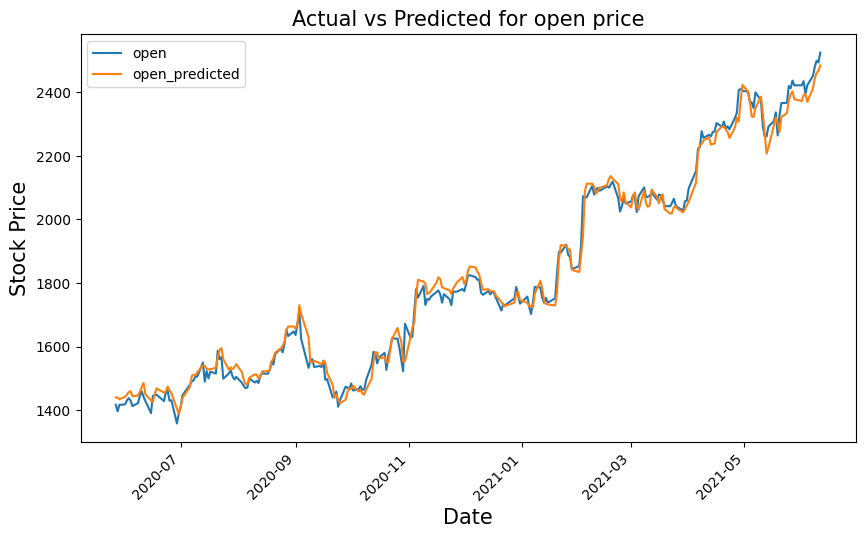

In [38]:
df_merge[['open','open_predicted']].plot(figsize=(10,6))
plt.xticks(rotation=45)
plt.xlabel('Date',size=15)
plt.ylabel('Stock Price',size=15)
plt.title('Actual vs Predicted for open price',size=15)
plt.show()

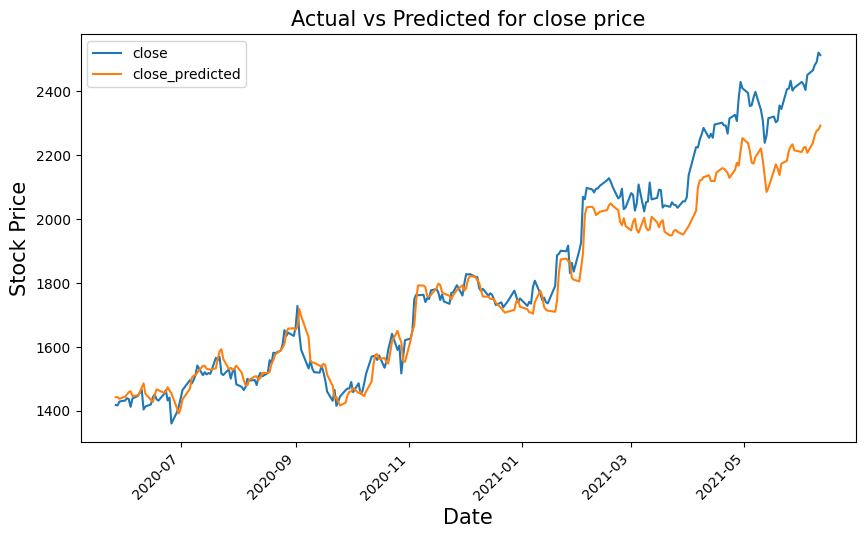

In [39]:
df_merge[['close','close_predicted']].plot(figsize=(10,6))
plt.xticks(rotation=45)
plt.xlabel('Date',size=15)
plt.ylabel('Stock Price',size=15)
plt.title('Actual vs Predicted for close price',size=15)
plt.show()

In [40]:
new_data = pd.DataFrame(index=pd.date_range(start=df_merge.index[-1], periods=11, freq='D'))

df_merge = pd.concat([df_merge, new_data])

selected_date_range = df_merge['2021-06-09':'2021-06-28']
print(selected_date_range)

               open    close  open_predicted  close_predicted
2021-06-09  2499.50  2491.40     2461.447998      2276.339844
2021-06-10  2494.01  2521.60     2467.161377      2280.357178
2021-06-11  2524.92  2513.93     2484.585693      2292.988037
2021-06-11      NaN      NaN             NaN              NaN
2021-06-12      NaN      NaN             NaN              NaN
2021-06-13      NaN      NaN             NaN              NaN
2021-06-14      NaN      NaN             NaN              NaN
2021-06-15      NaN      NaN             NaN              NaN
2021-06-16      NaN      NaN             NaN              NaN
2021-06-17      NaN      NaN             NaN              NaN
2021-06-18      NaN      NaN             NaN              NaN
2021-06-19      NaN      NaN             NaN              NaN
2021-06-20      NaN      NaN             NaN              NaN
2021-06-21      NaN      NaN             NaN              NaN


In [41]:
upcoming_prediction = pd.DataFrame(columns=['open','close'],index=df_merge.index)
upcoming_prediction.index=pd.to_datetime(upcoming_prediction.index)

In [42]:
curr_seq = test_seq[-1:]

for i in range(-10,0):
  up_pred = model.predict(curr_seq)
  upcoming_prediction.iloc[i] = up_pred
  curr_seq = np.append(curr_seq[0][1:],up_pred,axis=0)
  curr_seq = curr_seq.reshape(test_seq[-1:].shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


In [43]:
upcoming_prediction[['open','close']] = MMS.inverse_transform(upcoming_prediction[['open','close']])

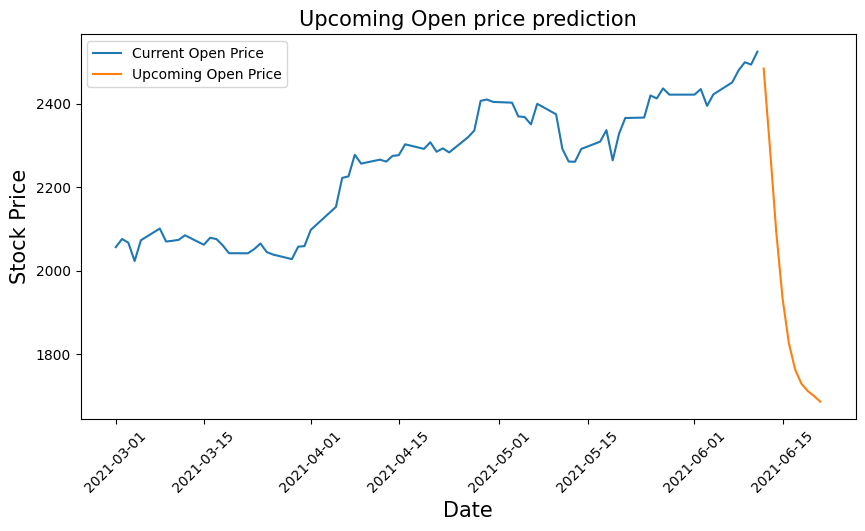

In [44]:
fig,ax=plt.subplots(figsize=(10,5))
ax.plot(df_merge.loc['2021-03-01':,'open'],label='Current Open Price')
ax.plot(upcoming_prediction.loc['2021-04-01':,'open'],label='Upcoming Open Price')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.set_xlabel('Date',size=15)
ax.set_ylabel('Stock Price',size=15)
ax.set_title('Upcoming Open price prediction',size=15)
ax.legend()
fig.show()


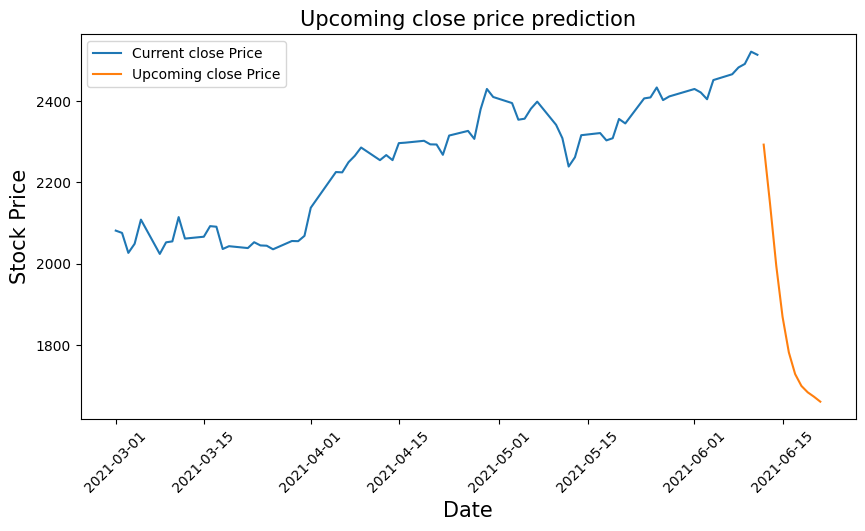

In [45]:
fig,ax=plt.subplots(figsize=(10,5))
ax.plot(df_merge.loc['2021-03-01':,'close'],label='Current close Price')
ax.plot(upcoming_prediction.loc['2021-04-01':,'close'],label='Upcoming close Price')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.set_xlabel('Date',size=15)
ax.set_ylabel('Stock Price',size=15)
ax.set_title('Upcoming close price prediction',size=15)
ax.legend()
fig.show()

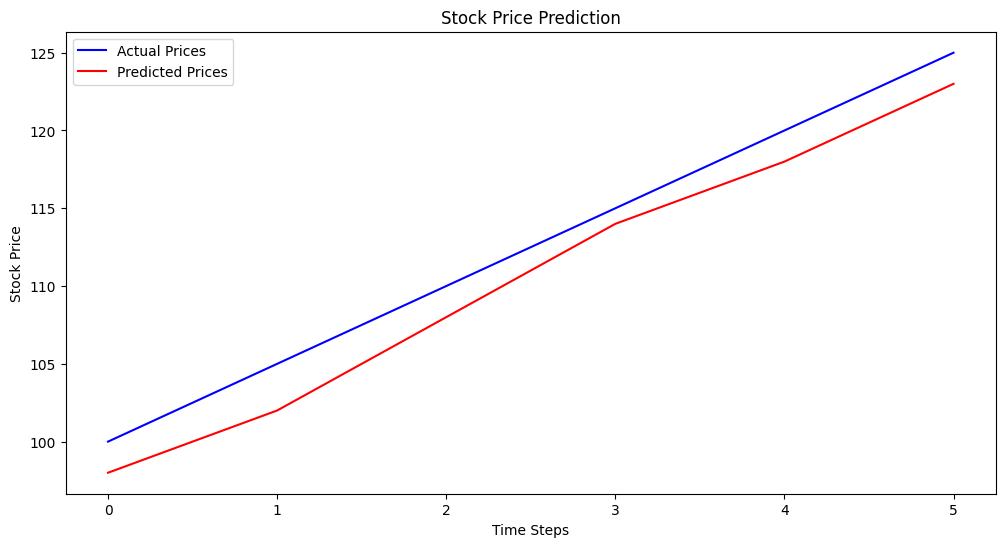

In [46]:
actual_prices = np.array([100, 105, 110, 115, 120, 125])  # Example actual prices

# Define predicted stock prices (replace [...] with your predicted data)
predictions = np.array([98, 102, 108, 114, 118, 123])  # Example predicted prices

# Plotting the actual and predicted prices
plt.figure(figsize=(12, 6))
plt.plot(actual_prices, label='Actual Prices', color='blue')
plt.plot(predictions, label='Predicted Prices', color='red')
plt.xlabel('Time Steps')
plt.ylabel('Stock Price')
plt.title('Stock Price Prediction')
plt.legend()
plt.show()

In [50]:
close_prices = df['close'].values.reshape(-1, 1)  # Reshape for MinMaxScaler

# Perform Min-Max scaling
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
close_prices_scaled = scaler.fit_transform(close_prices)

In [52]:
close_prices = df['close'].values.reshape(-1, 1)  # Reshape for MinMaxScaler

# Perform Min-Max scaling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_close_prices = scaler.fit_transform(close_prices)

In [53]:
def create_lstm_dataset(data, time_steps=1):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:(i + time_steps), 0])
        y.append(data[i + time_steps, 0])
    return np.array(X), np.array(y)

# Create LSTM dataset
X, y = create_lstm_dataset(scaled_close_prices, time_steps=10)

In [54]:
split_ratio = 0.8  # 80% for training, 20% for testing

split_index = int(len(X) * split_ratio)
X_train, X_test, y_train, y_test = X[:split_index], X[split_index:], y[:split_index], y[split_index:]

In [55]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(LSTM(units=50))
model.add(Dense(units=1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

In [56]:
epochs = 50  # You can adjust this based on your preference
batch_size = 32  # You can adjust this based on your preference

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])

# Train the LSTM model
history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size)


Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.0000e+00 - loss: 0.0218
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.0000e+00 - loss: 0.0014
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0000e+00 - loss: 4.6163e-04
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0000e+00 - loss: 3.8342e-04
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.0000e+00 - loss: 3.7654e-04
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.0000e+00 - loss: 3.5951e-04
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0000e+00 - loss: 3.4494e-04
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0000e+00 - loss: 3.8264e-04
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0000e+00 - loss: 3.6849e-04
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.0000e+00 - loss: 3.5230e-04
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.0000e+00 - 

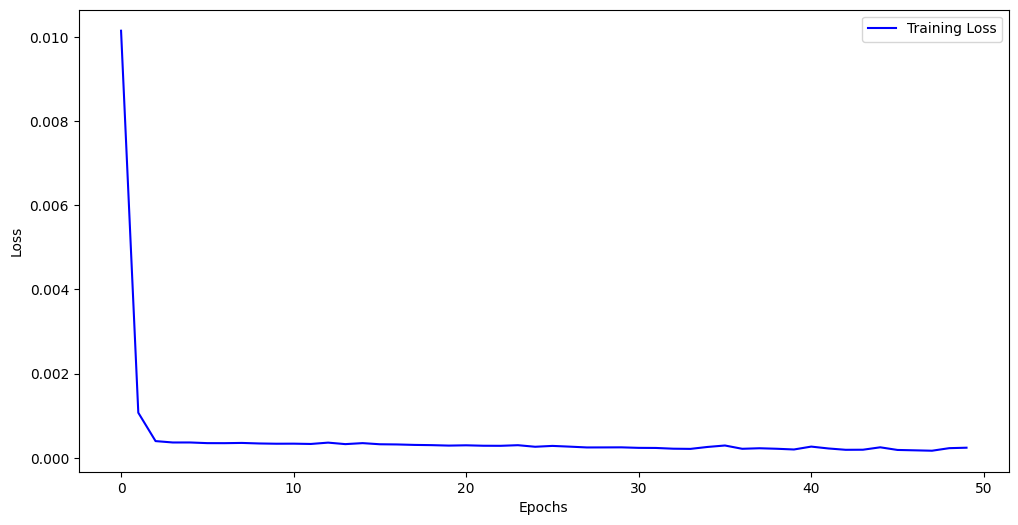

In [57]:
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


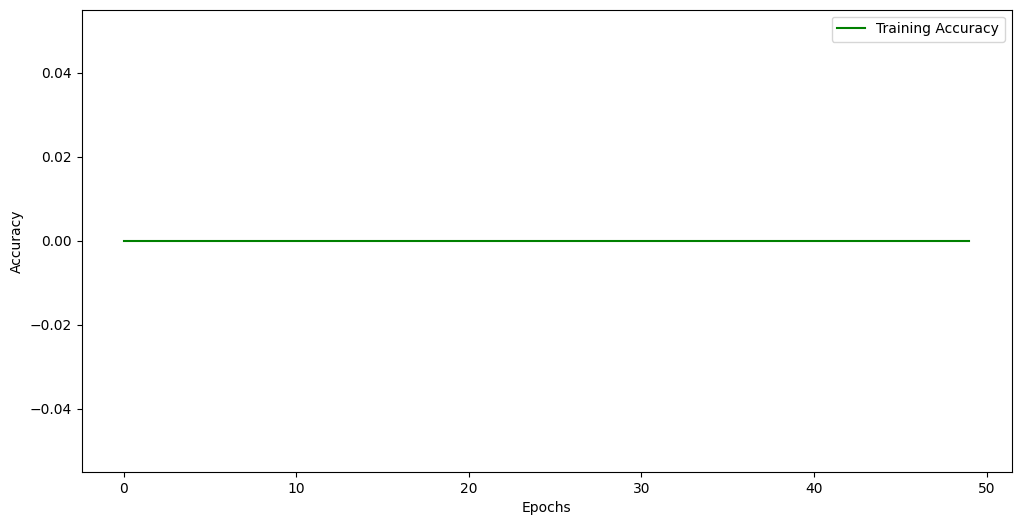

In [58]:
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='green')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [59]:
predicted_prices = model.predict(X_test)
predicted_prices = scaler.inverse_transform(predicted_prices)  # Inverse transform the predictions

# Assuming y_test contains the actual stock prices for the test data
from sklearn.metrics import mean_squared_error

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, predicted_prices))
print('Root Mean Squared Error (RMSE):', rmse)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step
Root Mean Squared Error (RMSE): 0.046235696196601984


In [60]:
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
X_test = scaler.inverse_transform(X_test.reshape(-1, 1))

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


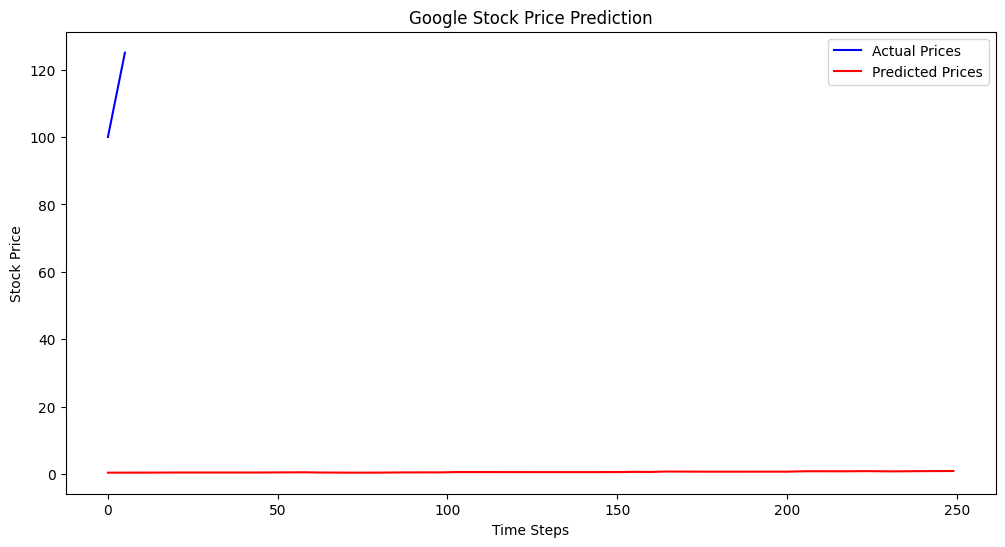

In [61]:
plt.figure(figsize=(12, 6))
plt.plot(actual_prices, label='Actual Prices', color='blue')
plt.plot(predictions, label='Predicted Prices', color='red')
plt.xlabel('Time Steps')
plt.ylabel('Stock Price')
plt.title('Google Stock Price Prediction')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step


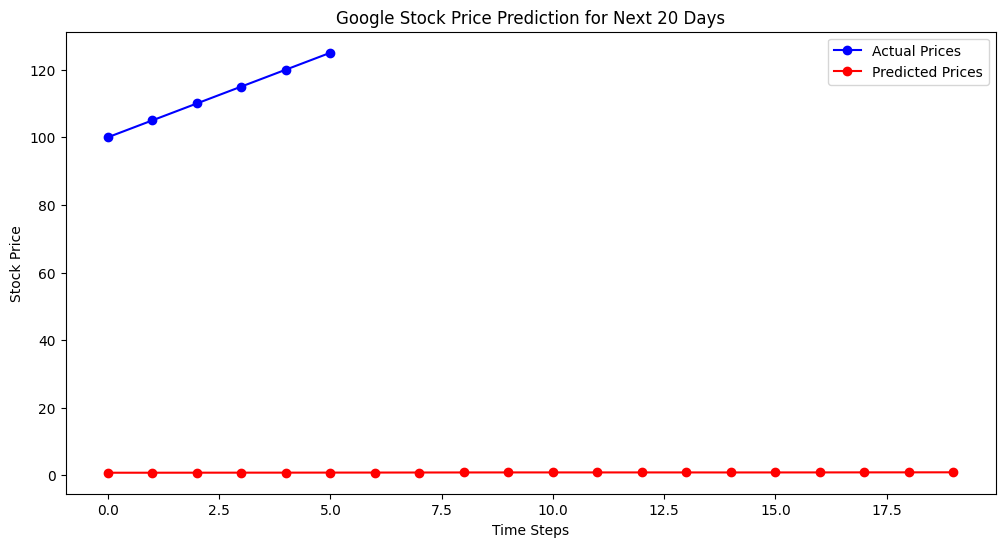

In [62]:
plt.figure(figsize=(12, 6))
plt.plot(actual_prices[-20:], label='Actual Prices', color='blue', marker='o')
predicted_future_prices = model.predict(X[-20:])
predicted_future_prices = scaler.inverse_transform(predicted_future_prices)
plt.plot(predicted_future_prices, label='Predicted Prices', color='red', marker='o')
plt.xlabel('Time Steps')
plt.ylabel('Stock Price')
plt.title('Google Stock Price Prediction for Next 20 Days')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


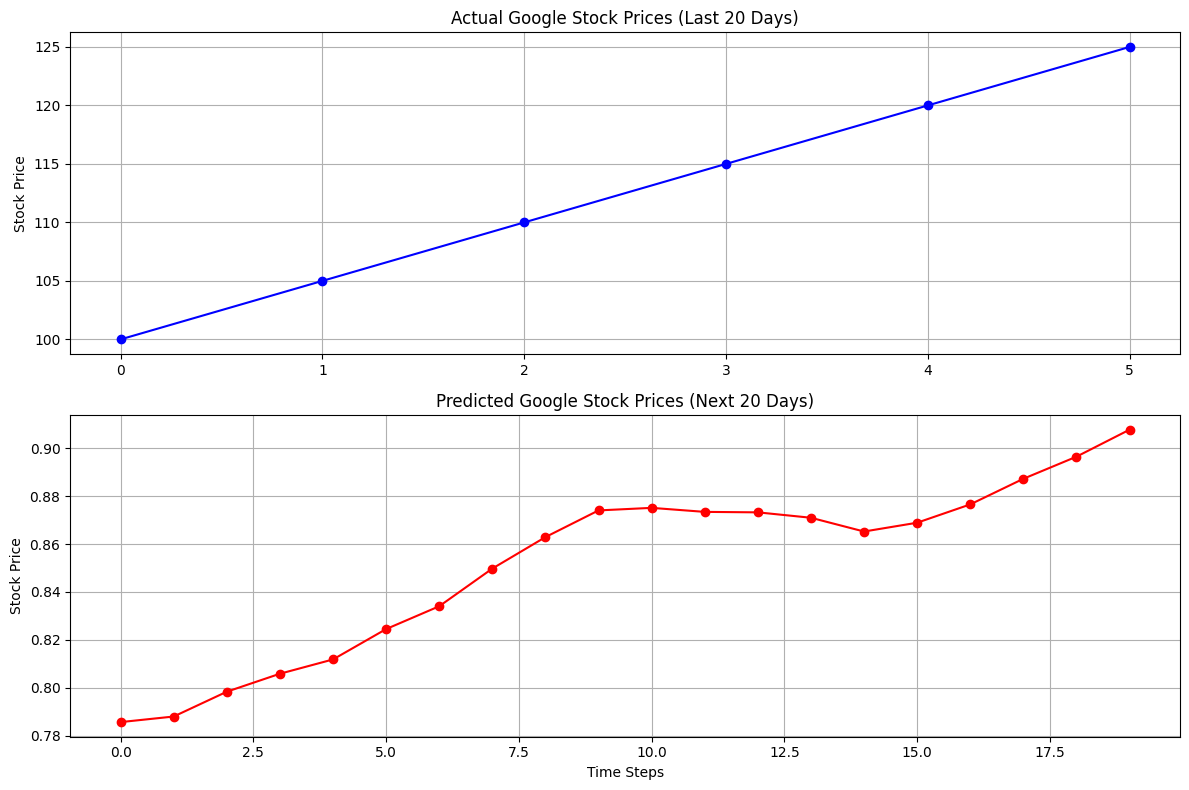

In [63]:
plt.figure(figsize=(12, 8))

# Plot 1: Actual Prices
plt.subplot(2, 1, 1)
plt.plot(actual_prices[-20:], color='blue', marker='o')
plt.title('Actual Google Stock Prices (Last 20 Days)')
plt.ylabel('Stock Price')
plt.grid(True)

# Predict future prices
predicted_future_prices = model.predict(X[-20:])
predicted_future_prices = scaler.inverse_transform(predicted_future_prices)

# Plot 2: Predicted Prices
plt.subplot(2, 1, 2)
plt.plot(predicted_future_prices, color='red', marker='o')
plt.title('Predicted Google Stock Prices (Next 20 Days)')
plt.xlabel('Time Steps')
plt.ylabel('Stock Price')
plt.grid(True)

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step


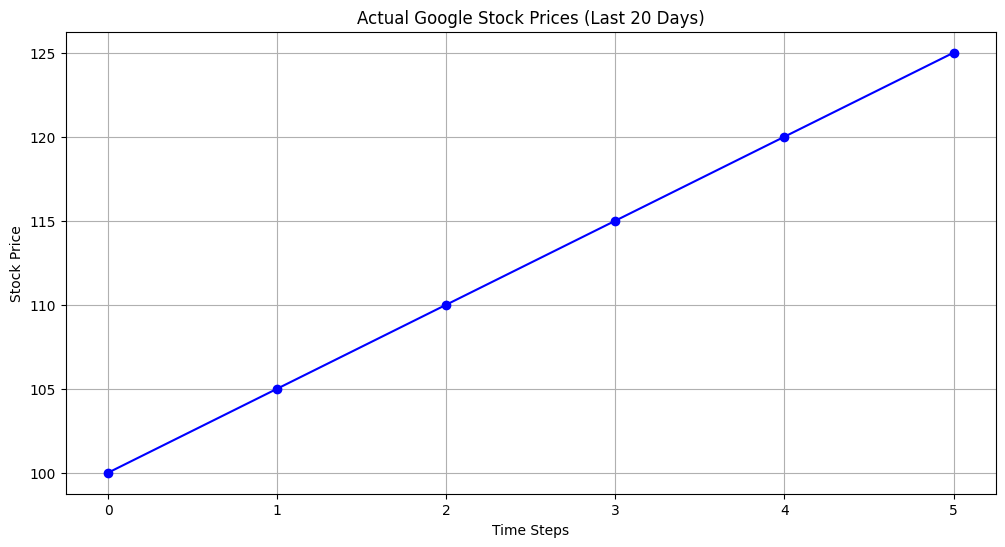

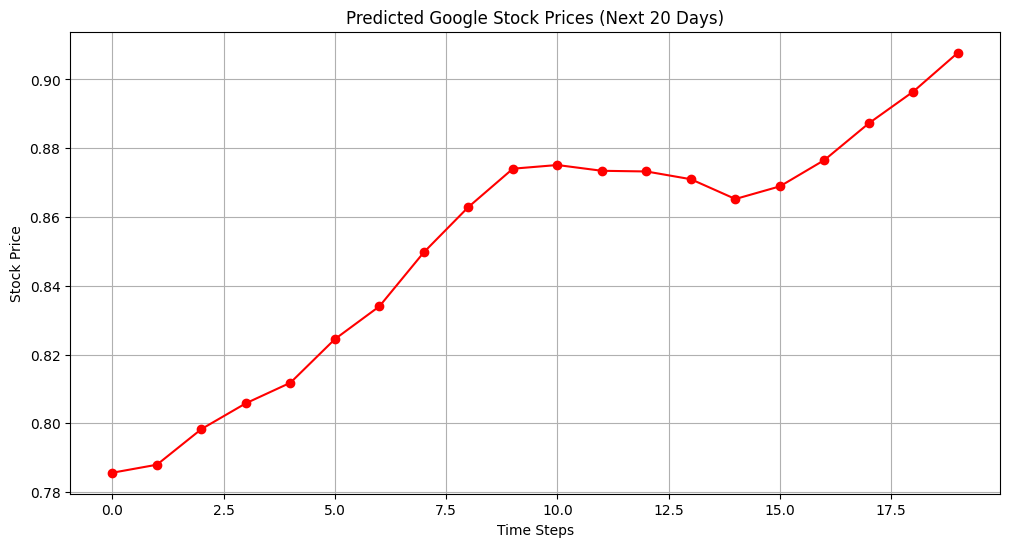

In [64]:
# Predict future prices
predicted_future_prices = model.predict(X[-20:])
predicted_future_prices = scaler.inverse_transform(predicted_future_prices)

# Actual Prices plot
plt.figure(figsize=(12, 6))
plt.plot(actual_prices[-20:], color='blue', marker='o')
plt.title('Actual Google Stock Prices (Last 20 Days)')
plt.xlabel('Time Steps')
plt.ylabel('Stock Price')
plt.grid(True)
plt.show()

# Predicted Prices plot
plt.figure(figsize=(12, 6))
plt.plot(predicted_future_prices, color='red', marker='o')
plt.title('Predicted Google Stock Prices (Next 20 Days)')
plt.xlabel('Time Steps')
plt.ylabel('Stock Price')
plt.grid(True)
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


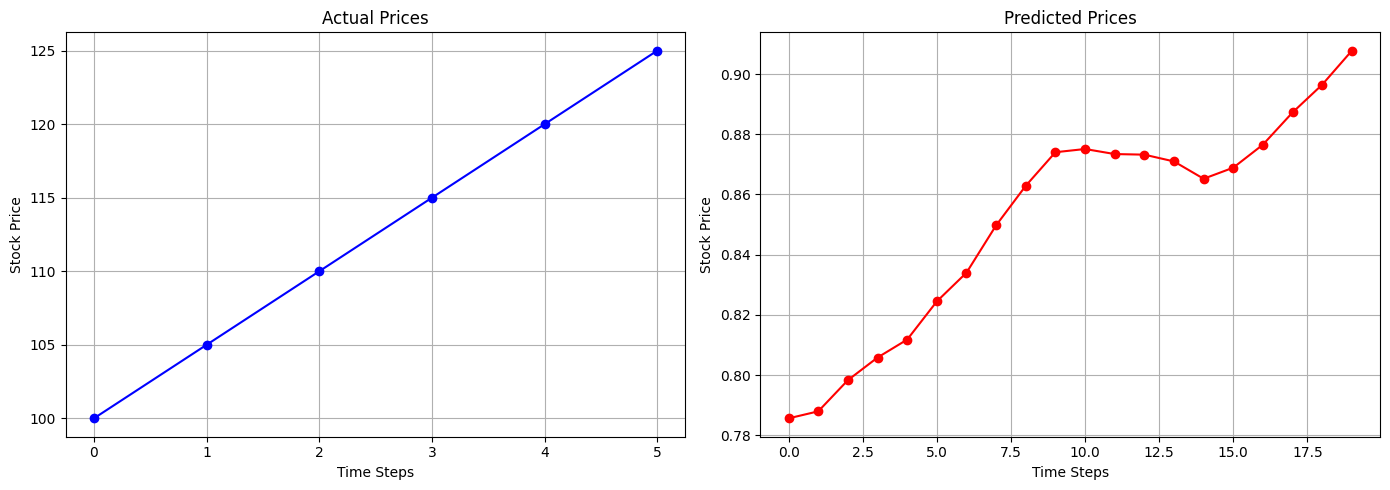

In [65]:
plt.figure(figsize=(14, 5))

# Actual Prices
plt.subplot(1, 2, 1)
plt.plot(actual_prices[-20:], color='blue', marker='o')
plt.title('Actual Prices')
plt.xlabel('Time Steps')
plt.ylabel('Stock Price')
plt.grid(True)

# Predicted Prices
predicted_future_prices = model.predict(X[-20:])
predicted_future_prices = scaler.inverse_transform(predicted_future_prices)

plt.subplot(1, 2, 2)
plt.plot(predicted_future_prices, color='red', marker='o')
plt.title('Predicted Prices')
plt.xlabel('Time Steps')
plt.ylabel('Stock Price')
plt.grid(True)

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


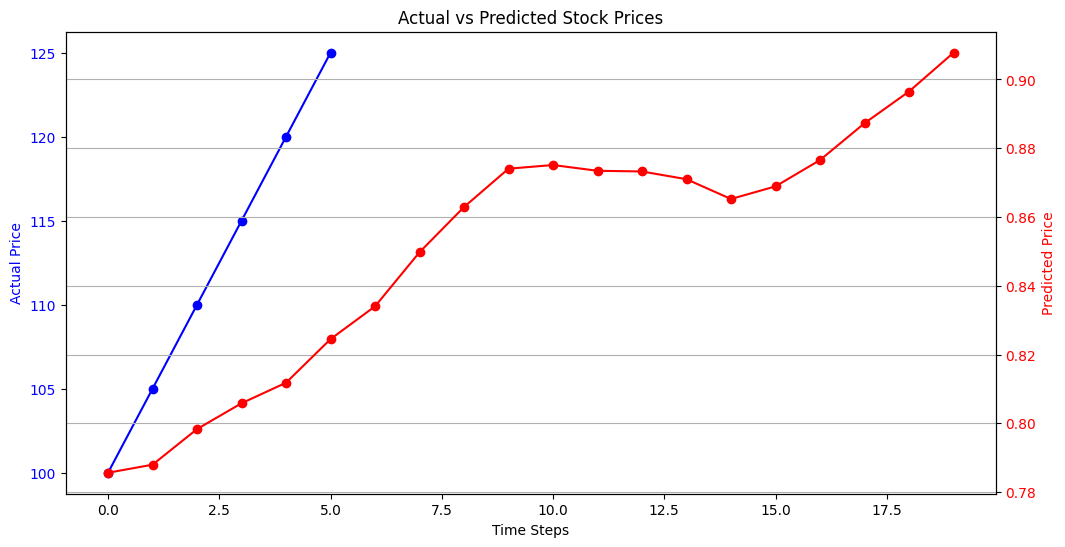

In [66]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(actual_prices[-20:], color='blue', marker='o')
ax1.set_xlabel('Time Steps')
ax1.set_ylabel('Actual Price', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

predicted_future_prices = model.predict(X[-20:])
predicted_future_prices = scaler.inverse_transform(predicted_future_prices)

ax2 = ax1.twinx()
ax2.plot(predicted_future_prices, color='red', marker='o')
ax2.set_ylabel('Predicted Price', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Actual vs Predicted Stock Prices')
plt.grid(True)
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


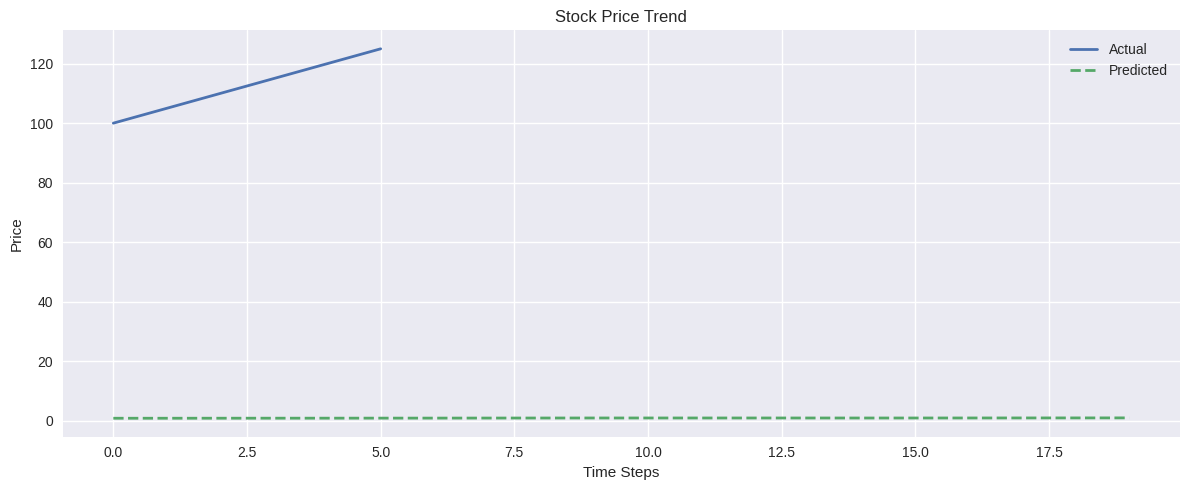

In [68]:
plt.figure(figsize=(12, 5))
plt.style.use('seaborn-v0_8')

predicted_future_prices = model.predict(X[-20:])
predicted_future_prices = scaler.inverse_transform(predicted_future_prices)

plt.plot(actual_prices[-20:], label='Actual', linewidth=2)
plt.plot(predicted_future_prices, label='Predicted', linestyle='--', linewidth=2)
plt.title('Stock Price Trend')
plt.xlabel('Time Steps')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()


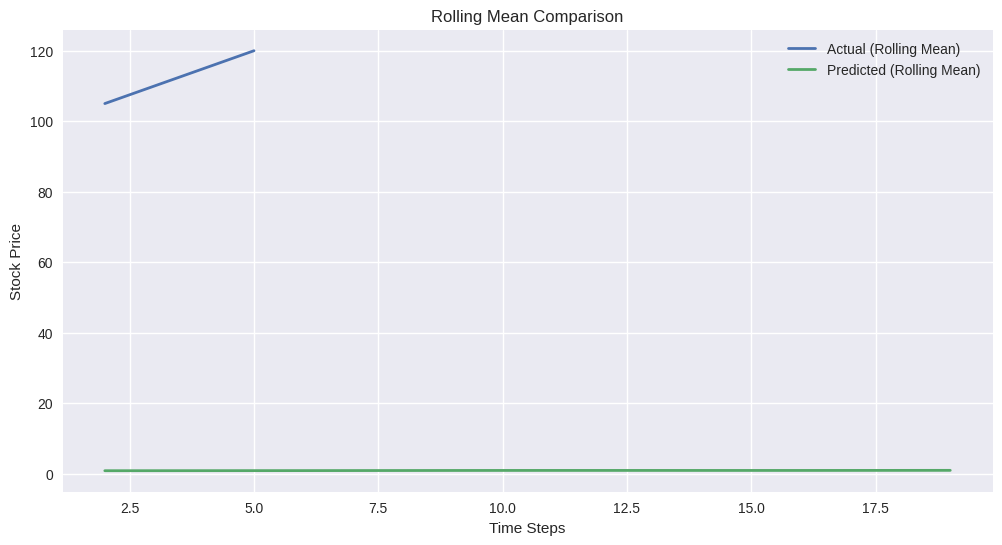

In [75]:
import pandas as pd

actual_series = pd.Series(actual_prices[-20:])
predicted_series = pd.Series(predicted_future_prices.flatten())

plt.figure(figsize=(12, 6))
plt.plot(actual_series.rolling(3).mean(), label='Actual (Rolling Mean)', linewidth=2)
plt.plot(predicted_series.rolling(3).mean(), label='Predicted (Rolling Mean)', linewidth=2)

plt.title('Rolling Mean Comparison')
plt.xlabel('Time Steps')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step


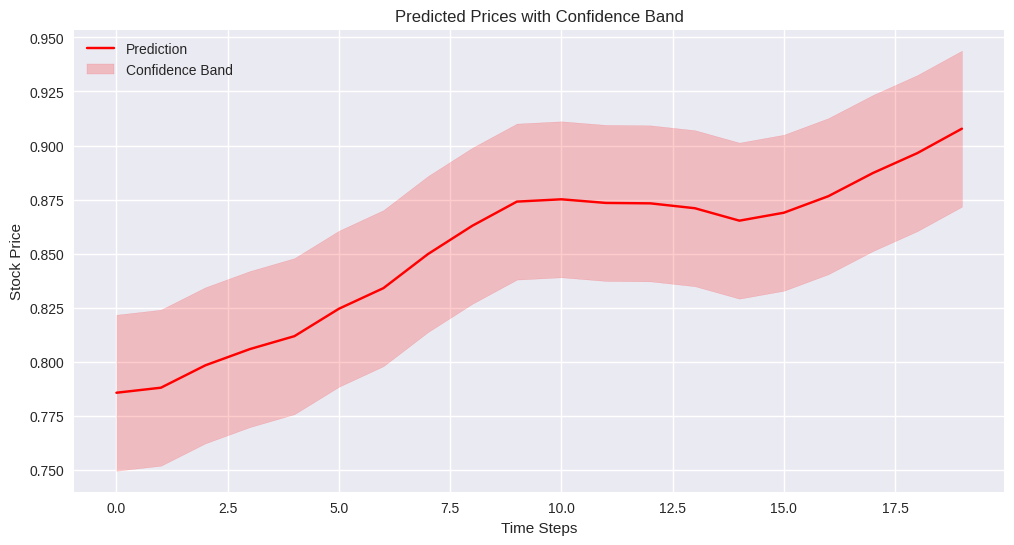

In [76]:
import numpy as np

predicted_future_prices = model.predict(X[-20:])
predicted_future_prices = scaler.inverse_transform(predicted_future_prices).flatten()

upper = predicted_future_prices + np.std(predicted_future_prices)
lower = predicted_future_prices - np.std(predicted_future_prices)

plt.figure(figsize=(12, 6))
plt.plot(predicted_future_prices, color='red', label='Prediction')
plt.fill_between(range(20), lower, upper, color='red', alpha=0.2, label='Confidence Band')

plt.title('Predicted Prices with Confidence Band')
plt.xlabel('Time Steps')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.show()


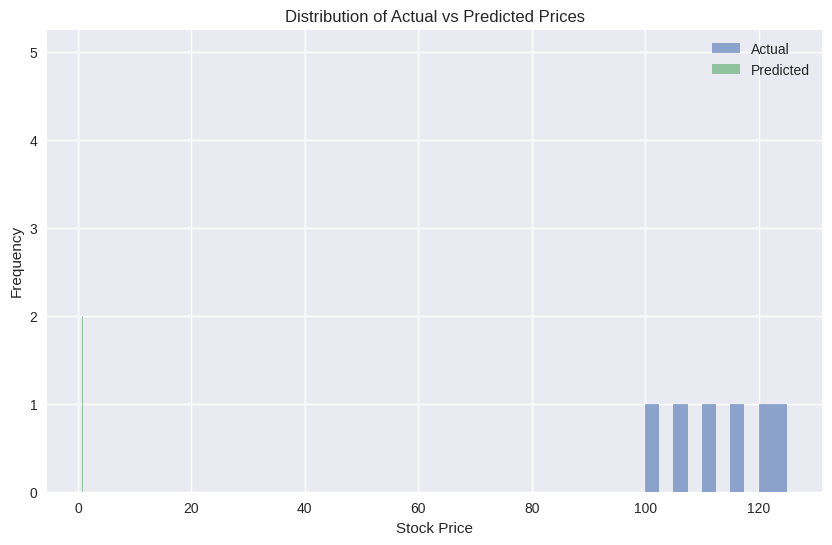

In [78]:
plt.figure(figsize=(10, 6))
plt.hist(actual_prices[-20:], bins=10, alpha=0.6, label='Actual')
plt.hist(predicted_future_prices, bins=10, alpha=0.6, label='Predicted')

plt.title('Distribution of Actual vs Predicted Prices')
plt.xlabel('Stock Price')
plt.ylabel('Frequency')
plt.legend()
plt.show()


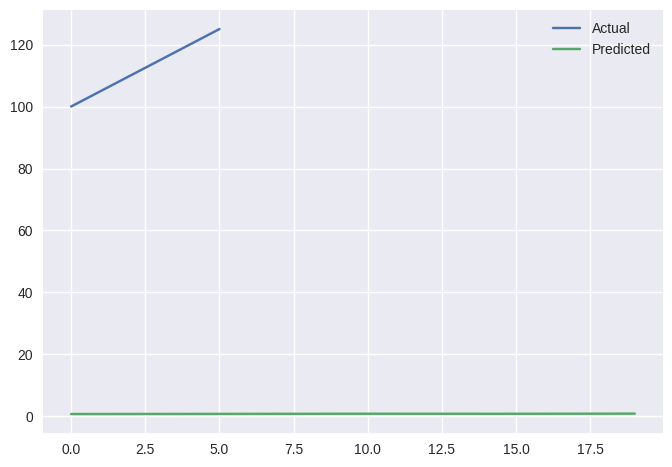

In [80]:
plt.plot(actual_prices[-20:], label='Actual')
plt.plot(predicted_future_prices.flatten(), label='Predicted')
plt.legend()


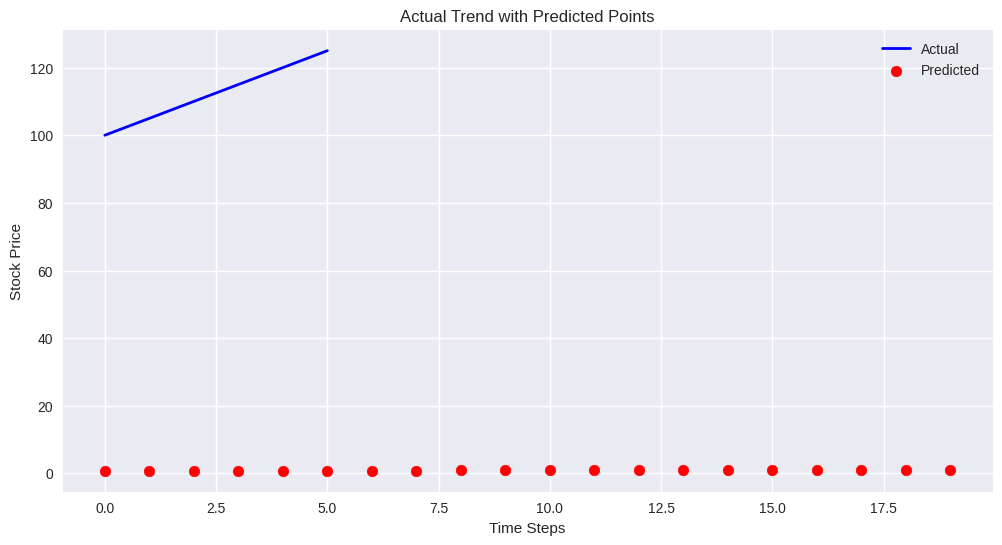

In [81]:
plt.figure(figsize=(12, 6))

plt.plot(actual_prices[-20:], color='blue', linewidth=2, label='Actual')
plt.scatter(range(len(predicted_future_prices)),
            predicted_future_prices.flatten(),
            color='red', s=60, label='Predicted')

plt.title('Actual Trend with Predicted Points')
plt.xlabel('Time Steps')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.show()


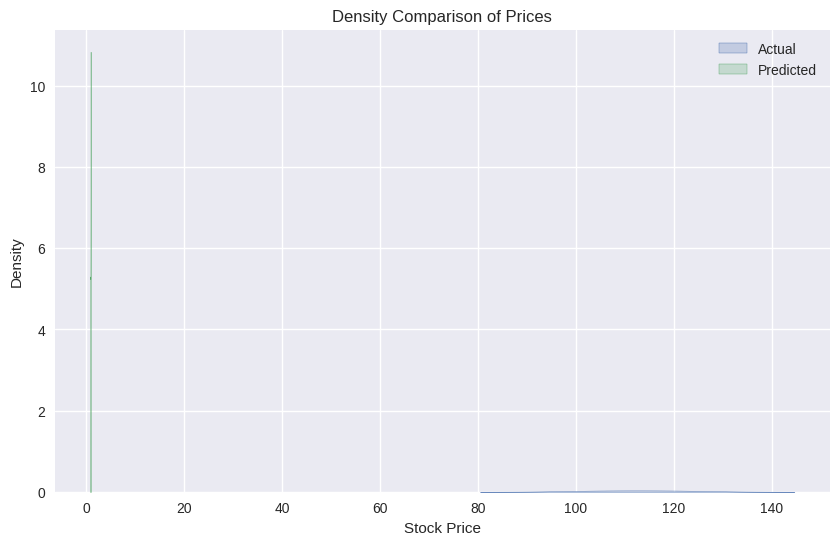

In [94]:
plt.figure(figsize=(10, 6))
sns.kdeplot(actual_prices[-20:], label='Actual', fill=True)
sns.kdeplot(predicted_future_prices.flatten(), label='Predicted', fill=True)

plt.title('Density Comparison of Prices')
plt.xlabel('Stock Price')
plt.legend()
plt.show()


